In [1]:
import dynamiqs as dq
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Task 1.3 Part b
Now we want to include single photon loss in the memory mode. This should amount to adding a $\kappa_a D(a)$ term in the Lindblad equation where $\kappa_a$ is the single photon loss rate of mode a. 

|          |   0.0% ◆ elapsed 0.00ms ◆ remaining ?
|██████████| 100.0% ◆ elapsed 434.72ms ◆ remaining 0.00ms  

100%|██████████| 50/50 [00:08<00:00,  5.87it/s]


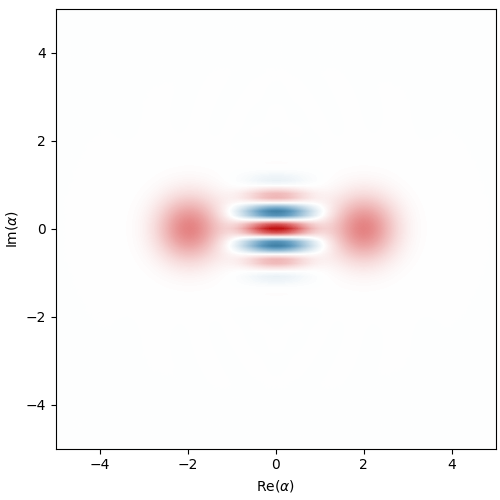

In [22]:
na, nb = 20, 5  # Hilbert space dimensions
g2 = 1.0  # Two-photon coupling strength
eps_d = -4  # Drive amplitude
alpha = jnp.sqrt(-1.0*eps_d/g2)
kappa_b = 10  # Decay rate
kappa_a = 0.1 # Single-photon loss rate
psi0 = dq.tensor(dq.unit(dq.coherent(na, alpha) + dq.coherent(na, -alpha)), dq.fock(nb,0))  # Initial state
eps_z = 1 
T_z = jnp.pi/(4*alpha*eps_z)
T = 5*T_z

a, b = dq.destroy(na, nb)
dag_a, dag_b = dq.dag(a), dq.dag(b)
H_2ph = g2 * dag_a @ dag_a @ b + jnp.conj(g2) * a @ a @ dag_b
H_d = jnp.conj(eps_d) * b + eps_d * dag_b
H_z = eps_z*(dag_a + a)
H = H_2ph + H_d + H_z
exp_ops = [dq.dag(a) @ a, dq.dag(b) @ b]
loss_op = [jnp.sqrt(kappa_b) * b, jnp.sqrt(kappa_a)*a]

t_save = jnp.linspace(0, T, 100)
res = dq.mesolve(H, loss_op, psi0, t_save, exp_ops=exp_ops)
rho_a = dq.ptrace(res.states, 0)
# Then plot Wigner gif of rho_a
dq.plot.wigner_gif(rho_a)

(0.0, 1.5)

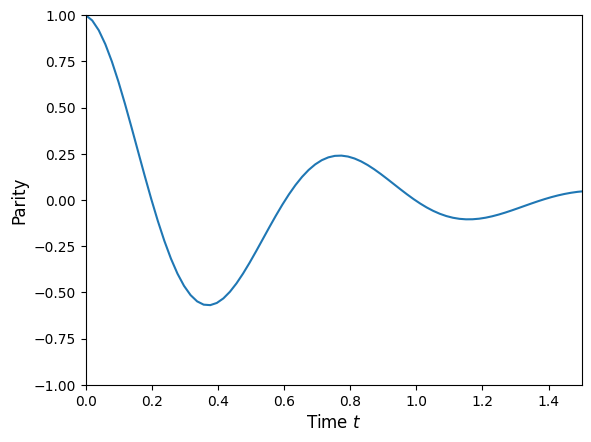

In [23]:
plt.plot(t_save, dq.expect(dq.parity(na), rho_a).real)
plt.xlabel(r"Time $t$", fontsize=12)
plt.ylabel(r"Parity", fontsize=12)
plt.ylim(-1, 1.0)
plt.xlim(0,1.5)